In [1]:
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA

import pmdarima as pm #auto arima
import scipy.io as sio
import os


## Load the intrinsic timescale time series

In [10]:
data_folder = '/Users/jiangruitong/Library/CloudStorage/GoogleDrive-ruitongj@andrew.cmu.edu/Shared drives/NML_shared/PapersInPrep/Journals/Larry/Temporal Correlations and Performance Fluctuation'

alpha = pd.read_csv(os.path.join(data_folder, 'timescale_alpha.csv'),parse_dates=['Time'], index_col='Time')
beta = pd.read_csv(os.path.join(data_folder, 'timescale_beta.csv'),parse_dates=['Time'], index_col='Time')
delta = pd.read_csv(os.path.join(data_folder, 'timescale_delta.csv'),parse_dates=['Time'], index_col='Time')
theta = pd.read_csv(os.path.join(data_folder, 'timescale_theta.csv'),parse_dates=['Time'], index_col='Time')

In [12]:
alpha

,Virgil,Goku,Baldface
Time,,,
2022-09-02 06:01:00,1.0,1.0,4.5
2022-09-02 06:01:30,1.0,4.5,1.5
2022-09-02 06:02:00,1.0,9.5,4.0
2022-09-02 06:02:30,1.5,3.5,1.0
2022-09-02 06:03:00,1.5,3.0,0.5
...,...,...,...
2022-09-14 05:57:00,1.0,2.5,2.5
2022-09-14 05:57:30,5.0,2.5,2.5
2022-09-14 05:58:00,5.5,3.5,2.5


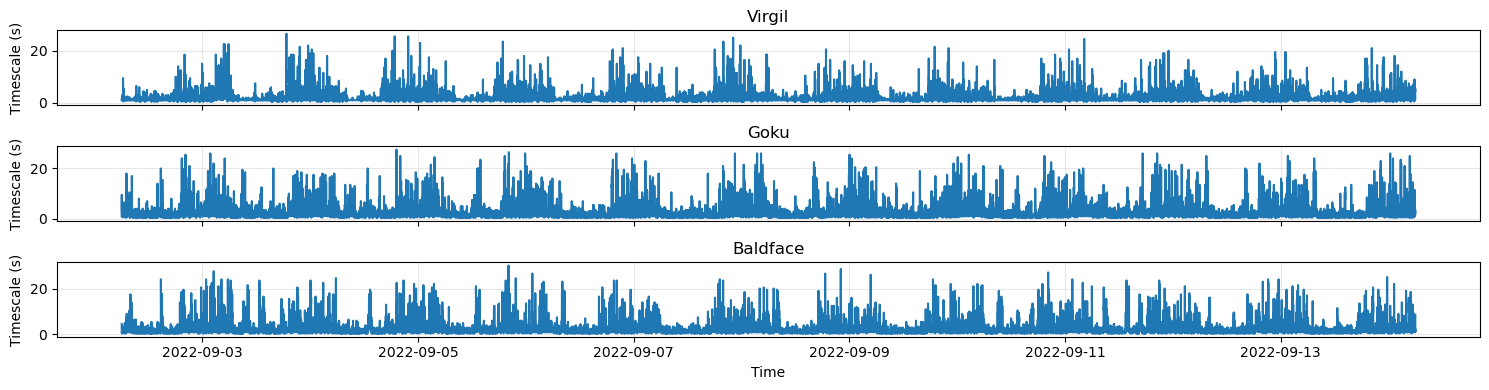

In [13]:
def plot_subject_subplots(df, subject_cols=None, figsize=(15, 4)):
    if subject_cols is None:
        subject_cols = df.columns.tolist()
    
    if len(subject_cols) != 3:
        raise ValueError("Please provide exactly 3 subject columns for plotting.")
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    for ax, subj in zip(axes, subject_cols):
        ax.plot(df.index, df[subj])
        ax.set_title(subj)
        ax.set_ylabel("Timescale (s)")
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    return fig, axes

fig,axes = plot_subject_subplots(alpha)


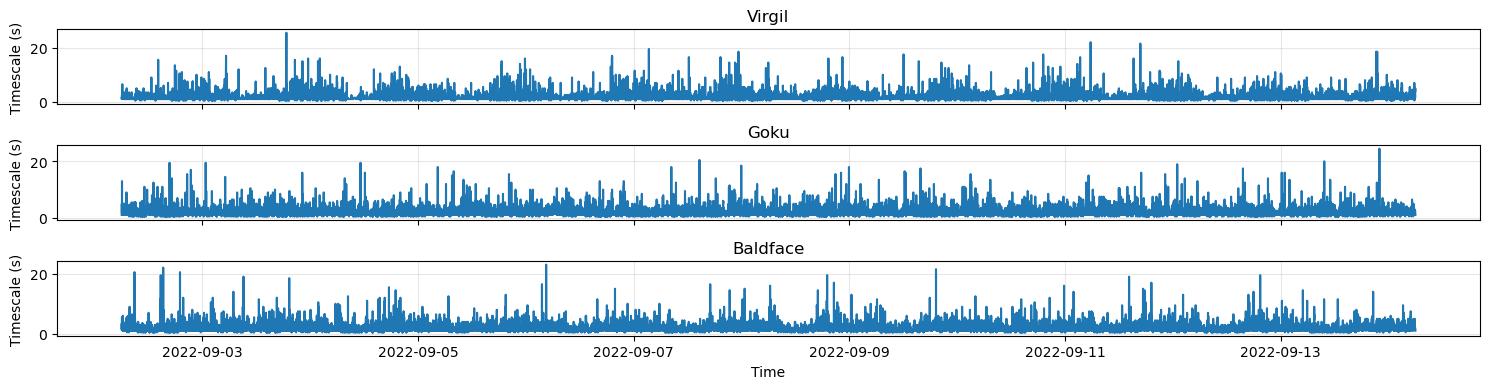

In [14]:
fig,axes = plot_subject_subplots(beta)

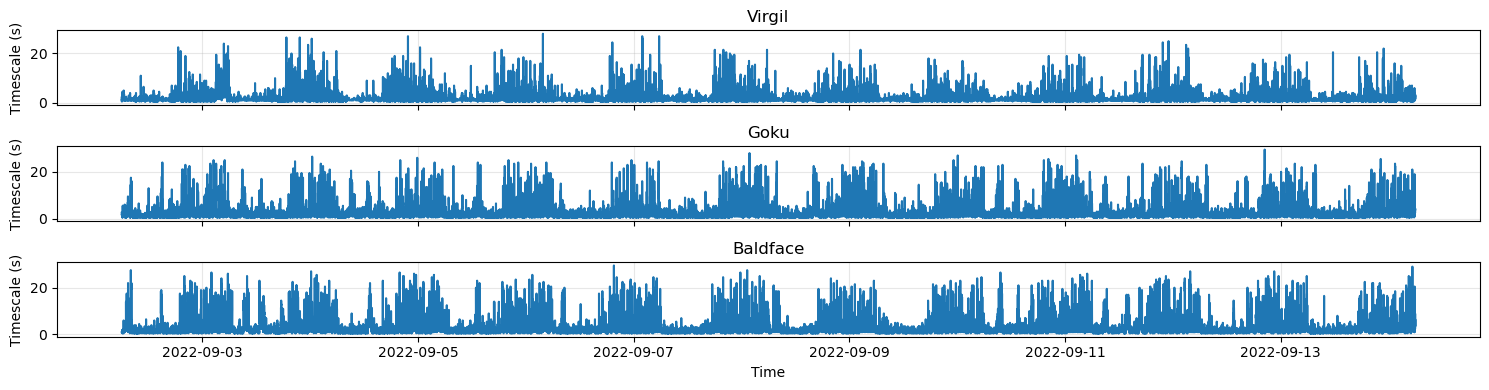

In [15]:
fig,axes = plot_subject_subplots(theta)

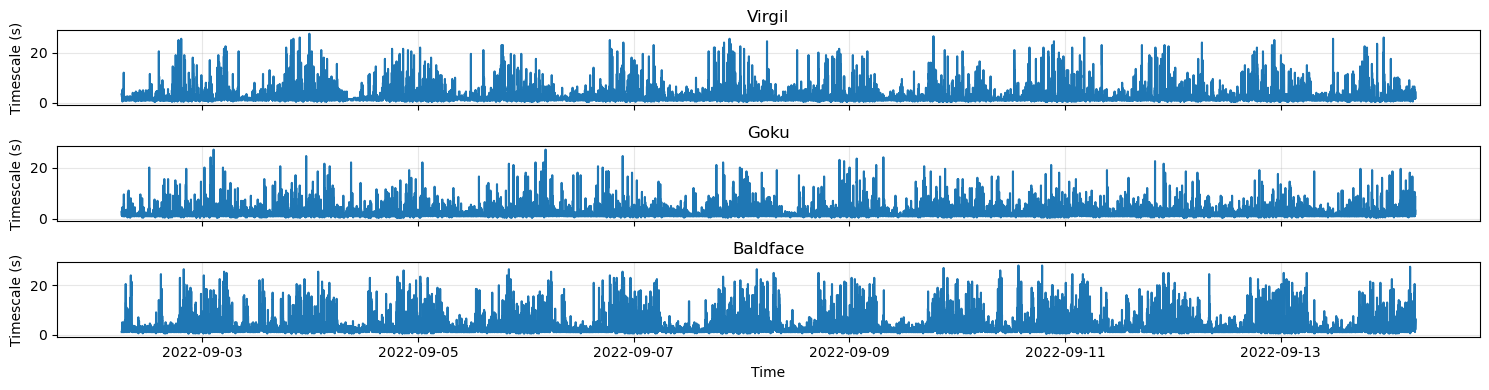

In [16]:
fig,axes = plot_subject_subplots(delta)

## Inspect the regime/state to decide what model to use to model the volatility

In [24]:
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.signal import argrelmin
def threshold_mixture(x,n_components=2,n_iter = 200, tol=1e-6):
    """
    input: x (values), n_components (number of mixture components), n_iter(max EM iterations), tol:float (convergence threshold)

    returns: threshold (value where P(burst component)=0.5), params(fitted parameters include weights, shapes, scales for each component)
    """
    x= np.asarray(x,dtype=float)
    x = x[x>0]
    n = len(x)
    k=n_components
    # Initialize parameters
    sorted_x = np.sort(x)
    split = np.array_split(sorted_x, k)
    shapes = np.array([np.mean(s)**2/np.var(s) for s in split])
    scales = np.array([np.var(s)/np.mean(s) for s in split])
    weights = np.ones(k)/k
    ll_prev = -np.inf
    for iteration in range(n_iter):
        resp = np.zeros((n,k))
        for j in range(k):
            resp[:,j]=weights[j]*stats.gamma.pdf(x, a=shapes[j], scale=scales[j])
        resp_sum = resp.sum(axis=1,keepdims=True)
        resp_sum = np.maximum(resp_sum,1e-10)
        resp /= resp_sum
    
         # calculate the log-likelihood
        ll = np.sum(np.log(np.maximum(resp_sum.ravel(),1e-300)))
        if abs(ll-ll_prev)<tol:
            break
        ll_prev = ll
        # M-step: update parameters
        nk = resp.sum(axis=0)
        weights = nk/n
        for j in range(k):
            r = resp[:,j]
            mean_j = np.sum(r*x)/nk[j]
            var_j = np.sum(r*(x-mean_j)**2)/nk[j]
            var_j = max(var_j,1e-10)
            shapes[j] = mean_j**2/var_j
            scales[j]=var_j/mean_j
    # Order components by mean (floor first, burst second)
    means = shapes*scales
    order = np.argsort(means)
    shapes = shapes[order]
    scales = scales[order]
    weights = weights[order]
    # Find threshold where P(burst)=0.5
    def diff_posterior(t):
        p0 = weights[0]*stats.gamma.pdf(t, a=shapes[0], scale=scales[0])
        p1 = weights[1]*stats.gamma.pdf(t, a=shapes[1], scale=scales[1])
        return (p1-p0)**2
    result = minimize_scalar(diff_posterior,
                             bounds=(means[0],means[1]),
                             method='bounded')
    threshold = result.x
    params = {
        'weights': weights,
        'shapes': shapes,
        'scales': scales,
        'means':means[order],
        'converged_iter':iteration,
        'log_likelihood':ll
    }
    return threshold, params
def threshold_otsu(x,n_bins=256):
    """ 
    find threshold that maximizes between-class variance
    input: x (values), n_bins (number of histogram bins)

    output: threshold(float), sigma_b_max(float)
    """
    x = np.asarray(x,dtype=float)
    counts, bin_edges = np.histogram(x, bins=n_bins)
    bin_centers = (bin_edges[:-1]+bin_edges[1:])/2
    counts = counts.astype(float)
    total = counts.sum()

    # Sweep all possible thresholds
    best_threshold = bin_centers[0]
    sigma_b_max = 0
    
    w0_cumulative = 0
    mu0_cumulative = 0
    mu_total = np.sum(counts*bin_centers)
    for i in range(len(bin_centers)):
        w0_cumulative += counts[i]
        if w0_cumulative==0:
            continue
        w1_cumulative = total - w0_cumulative
        if w1_cumulative==0:
            break
        mu0_cumulative += counts[i]*bin_centers[i]
        mu0 = mu0_cumulative/w0_cumulative
        mu1 = (mu_total - mu0_cumulative)/w1_cumulative
        sigma_b = (w0_cumulative/total)*(w1_cumulative/total)*(mu0-mu1)**2
        if sigma_b > sigma_b_max:
            sigma_b_max = sigma_b
            best_threshold = bin_centers[i]
    return best_threshold, sigma_b_max

def threshold_kde_antimode(x,bw='scott',n_grid=2048):
    """
    find local minimum in the density between the two modes
    input: x, bandwidth method for KDE, number of grid points for evaluation

    output: threshold (location of the antimode), kde (fitted kde object)
    density: density values on grid
    """
    x = np.asarray(x,dtype=float)
    kde=stats.gaussian_kde(x, bw_method=bw)
    grid = np.linspace(x.min(),np.percentile(x,99),n_grid)
    density = kde(grid)

    # get local minima 
    local_min_idx, = argrelmin(density,order=20)

    if len(local_min_idx)==0:
        region = (grid>np.median(x))&(grid<np.percentile(x,90))
        if region.any():
            sub_density = density[region]
            sub_grid = grid[region]
            min_idx = np.argmin(sub_density)
            threshold = sub_grid[min_idx]
        else:
            threshold = np.median(x)
    else:
        candidates=grid[local_min_idx]
        above_median = candidates[candidates>np.median(x)]
        if len(above_median)>0:
            threshold=above_median[0]
        else:
            threshold = candidates[0]
    return threshold, kde, grid, density
def find_threshold(x,method='all',verbose=True):
    """
    wrapper to run one or all threshold methods
    input: x (values), method ('mixture','otsu','kde','all'), verbose (whether to print results or not)
    """
    x=np.asarray(x,dtype=float)
    x=x[~np.isnan(x)]
    results = {}

    if method in ('mixture','all'):
        thresh,params = threshold_mixture(x)
        results['mixture']={'threshold':thresh,'params':params}

    if method in ('otsu','all'):
        thresh,sigma_b = threshold_otsu(x)
        results['otsu']={'threshold':thresh,'sigma_b':sigma_b}
    
    if method in ('kde','all'):
        thresh,kde,grid,density = threshold_kde_antimode(x)
        results['kde']={'threshold':thresh,'kde':kde,'grid':grid,'density':density}
    
    if verbose:
        print(f"\n Threshold estimates (n={len(x)}):")
        print(f" {'Method':<12} {'Threshold':>10}")
        print(f" {'-'*24}")
        for name, res in results.items():
            print(f" {name:<12} {res['threshold']:>10.2f}")

        if len(results)>1:
            thresholds=[r['threshold'] for r in results.values()]
            print(f"\n Range:{min(thresholds):.2f} - {max(thresholds):.2f}")
            print(f" Mean:{np.mean(thresholds):.2f}")
    return results

# Function for visualizing the diurnal differences of the TC values
def tc_day_night_distribution(df,light_on=6,light_off=19,max_tc=20,figsize=(14,12)):
    """
    input:
    df: time table with each column representing the TC associating with a subject
    light_on: hour of the day when light turns on (default 6 for 6am)
    light_off: hour of the day when light turns off (default 19 for 7pm)
    max_tc: float
    figsize:tuple

    return:
    fig: matplotlib.figure.Figure
    summary:pd.DataFrame (per-subject,per-regime summary statistics)
    """
    hour = df.index.hour
    is_day = (hour>=light_on) & (hour<light_off)
    subjects = df.columns.tolist()
    n_subj=len(subjects)
    fig,axes = plt.subplots(n_subj,3,figsize=figsize)
    if n_subj==1:
        axes = axes[np.newaxis,:]
    
    records = []
    for i,subj in enumerate(subjects):
        vals = df[subj].dropna()
        day =vals[is_day]
        night = vals[~is_day]
        u_stat,u_p = stats.mannwhitneyu(day,night,alternative='two-sided')
        ks_stat,ks_p = stats.ks_2samp(day,night)
        for regime, x in [('day',day),('night',night)]:
            records.append({
                'subject':subj,
                'regime':regime,
                'n':len(x),
                'mean':x.mean(),
                'std':x.std(),
                'median':x.median(),
                'iqr':x.quantile(0.75)-x.quantile(0.25),
                'cv':x.std()/x.mean(),
                'max':x.max(),
                'mann_whitney_p':u_p,
                'ks_p':ks_p,
                'night_day_ratio':night.mean()/day.mean()
            })
        # Col 1: distribution overlay
        ax = axes[i,0]
        bins = np.arange(0,vals.max()+0.5,0.5)
        ax.hist(day,bins = bins,density=True,alpha=0.5,color='orange',label='day')
        ax.hist(night,bins = bins,density=True,alpha=0.5,color='navy',label='night')
        ax.set_xlable('TC(s)')
        ax.set_ylabel('Density')
        ax.set_title(f"{subj}-Distribution")
        ax.legend()
        ax.set_xlim(0,max_tc)
        # Col 2: hourly mean with std error shade
        ax = axes[i,1]
        hourly = vals.groupby(vals.index.hour)
        h_mean = hourly.mean()
        h_std = hourly.std()
        ax.fill_between(h_mean.index,h_mean-h_std,h_mean+h_std,alpha=0.3,color='steelblue')
        ax.plot(h_mean.index,h_mean,'o-',color='steelblue',linewidth=2)
        ax.axvspan(0,light_on,color='gray',alpha=0.2)
        ax.axvspan(light_off,24,color='gray',alpha=0.2)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Mean TC(s)')
        ax.set_title(f"{subj}-Hourly Mean +/- Std")
        ax.set_xticks(range(0,24,3))
        # Col 3: volatility (CV and IQR)
        ax = axes[i,2]
        h_cv = h_std/h_mean
        h_iqr = hourly.quantile(0.75)-hourly.quantile(0.25)
        ax2 = ax.twinx()
        ax.bar(h_cv.index,h_cv,color='coral',alpha=0.6,label='CV')
        ax2.plot(h_iqr.index,h_iqr,'s-',color='darkgreen',linewidth=2,label='IQR')
        ax.axvspan(0,light_on,alpha=0.1,color='gray')
        ax.axvspan(light_off,24,alpha=0.1,color='gray')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('CV',color='coral')
        ax2.set_ylabel('IQR (s)',color='darkgreen')
        ax.set_title(f'{subj}-Volatility by hour')
        ax.set_xticks(range(0,24,3))
    plt.tight_layout()
    summary = pd.DataFrame(records).set_index(['subject','regime'])
    return fig, summary

def tc_hourly_volatility(df,light_on=6,light_off=19):
    subjects = df.columns.tolist()
    records = []
    for subj in subjects:
        vals = df[subj].dropna()
        for h in range(24):
            x=vals[vals.index.hour==h]
            if len(x)==0:
                continue
            records.append({
                'subject':subj,
                'hour':h,
                'is_light':(h>=light_on) & (h<light_off),
                'n':len(x),
                'mean':x.mean(),
                'std':x.std(),
                'median':x.median(),
                'iqr':x.quantile(0.75)-x.quantile(0.25),
                'cv':x.std()/x.mean(),
                'skew':x.skew(),
                'kurtosis':x.kurtosis(),
                'max':x.max()
            })
    hourly = pd.DataFrame(records).set_index(['subject','hour'])
    return hourly

def plot_mixture_fit(x,subj_name='',n_components=2,figsize=(10,5)):
    x=np.asarray(x,dtype=float)
    x=x[~np.isnan(x)]
    threshold,params = threshold_mixture(x,n_components=n_components)
    fig,ax = plt.subplots(figsize=figsize)
    bins = np.arange(0,np.percentile(x,99)+0.5,0.5)
    ax.hist(x,bins=bins,density=True,alpha=0.4,color='gray',label='Data')
    grid = np.linspace(0.01,np.percentile(x,99),500)
    colors = ['steelblue','firebrick','forestgreen']
    total_pdf = np.zeros_like(grid)
    for j in range(n_components):
        comp_pdf = (params['weights'][j]*
                    stats.gamma.pdf(grid,a=params['shapes'][j],
                                    scale=params['scales'][j]))
        total_pdf += comp_pdf
        label = (f"Component {j+1}: weight={params['weights'][j]:.2f}, "
                 f"mean={params['means'][j]:.2f}, ")
        ax.plot(grid,comp_pdf,color=colors[j%len(colors)],linewidth=2,label=label)
    ax.plot(grid,total_pdf,'k--',linewidth=1.5,label='Mixture total')
    ax.axvline(threshold,color='red',linestyle=':',linewidth=2,
               label=f'Crossover= {threshold:.2f}')
    ax.set_xlabel('TC (s)',fontsize=14)
    ax.set_ylabel('Density',fontsize=14)
    ax.set_title(f'{subj_name} - Gamma Mixture Fit' if subj_name
                 else 'Gamma mixture fit',fontsize=16)
    ax.legend(fontsize=10)
    ax.set_xlim(0,np.percentile(x,99))
    plt.tight_layout()
    return fig, threshold, params




Check alpha

In [25]:
for subj in alpha.columns:
    print(f"\n{'='*40}")
    print(f" {subj}")
    print(f"{'='*40}")

    # All data
    print("\n [Full recording]")
    results = find_threshold(alpha[subj].values)


 Virgil

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            2.80
 otsu               4.51
 kde                8.32

 Range:2.80 - 8.32
 Mean:5.21

 Goku

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            4.10
 otsu               6.04
 kde                9.70

 Range:4.10 - 9.70
 Mean:6.61

 Baldface

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.93
 otsu               5.97
 kde               11.12

 Range:3.93 - 11.12
 Mean:7.01


Check beta

In [26]:
for subj in beta.columns:
    print(f"\n{'='*40}")
    print(f" {subj}")
    print(f"{'='*40}")

    # All data
    print("\n [Full recording]")
    results = find_threshold(beta[subj].values)


 Virgil

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.00
 otsu               2.99
 kde                1.82

 Range:1.82 - 3.00
 Mean:2.61

 Goku

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            4.12
 otsu               2.98
 kde                1.80

 Range:1.80 - 4.12
 Mean:2.97

 Baldface

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.99
 otsu               3.00
 kde                1.78

 Range:1.78 - 3.99
 Mean:2.92


check delta

In [27]:
for subj in delta.columns:
    print(f"\n{'='*40}")
    print(f" {subj}")
    print(f"{'='*40}")

    # All data
    print("\n [Full recording]")
    results = find_threshold(delta[subj].values)


 Virgil

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.44
 otsu               6.04
 kde                8.14

 Range:3.44 - 8.14
 Mean:5.87

 Goku

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.43
 otsu               5.00
 kde                8.77

 Range:3.43 - 8.77
 Mean:5.73

 Baldface

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.62
 otsu               6.46
 kde               13.91

 Range:3.62 - 13.91
 Mean:8.00


check theta

In [28]:
for subj in theta.columns:
    print(f"\n{'='*40}")
    print(f" {subj}")
    print(f"{'='*40}")

    # All data
    print("\n [Full recording]")
    results = find_threshold(theta[subj].values)


 Virgil

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.29
 otsu               5.50
 kde                9.81

 Range:3.29 - 9.81
 Mean:6.20

 Goku

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            4.23
 otsu               6.45
 kde               10.38

 Range:4.23 - 10.38
 Mean:7.02

 Baldface

 [Full recording]

 Threshold estimates (n=34524):
 Method        Threshold
 ------------------------
 mixture            3.62
 otsu               6.45
 kde               13.33

 Range:3.62 - 13.33
 Mean:7.80
